
# 7. Modelo SVR 



## 7.1. Cargue de datos

In [7]:
import pandas as pd

# 1. Cargar datos

ruta = r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_imputados.csv"
df = pd.read_csv(ruta)


# 2. Convertir fecha y ordenar
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Fecha"]).sort_values("Fecha").reset_index(drop=True)

# 3. Definir target y predictores
target_col = "Calamar"
feature_cols = ["Achi", "ElBanco", "SaladoBlanco", "PuertoBerrio", "Barrancabermeja"]


# 4. Revisar estructura básica
print("Dimensión del dataset:", df.shape)
print("Rango temporal:", df["Fecha"].min(), "->", df["Fecha"].max())
print("\nColumnas:")
print(df.columns.tolist())

print("\nValores nulos por columna:")
print(df.isna().sum())

print("\nPrimeras filas:")
print(df.head())

Dimensión del dataset: (18398, 7)
Rango temporal: 1975-06-29 00:00:00 -> 2025-11-10 00:00:00

Columnas:
['Fecha', 'Calamar', 'Achi', 'ElBanco', 'SaladoBlanco', 'PuertoBerrio', 'Barrancabermeja']

Valores nulos por columna:
Fecha              0
Calamar            0
Achi               0
ElBanco            0
SaladoBlanco       0
PuertoBerrio       0
Barrancabermeja    0
dtype: int64

Primeras filas:
       Fecha  Calamar   Achi     ElBanco  SaladoBlanco  PuertoBerrio  \
0 1975-06-29    564.0  545.0  660.000000         216.0         359.0   
1 1975-06-30    562.0  550.0  669.163950         250.0         384.0   
2 1975-07-01    559.0  558.0  677.513705         230.0         408.0   
3 1975-07-02    564.0  587.0  695.025813         171.0         404.0   
4 1975-07-03    568.0  603.0  694.579859         172.0         411.0   

   Barrancabermeja  
0            230.0  
1            280.0  
2            280.0  
3            315.0  
4            285.0  


En conjunto, los resultados de la prueba de Ljung-Box y de la función de autocorrelación indican que las series de nivel analizadas presentan una dependencia temporal muy marcada y persistente, ya que en todas las estaciones y para todos los rezagos evaluados los valores-p fueron prácticamente nulos, lo que permite rechazar la hipótesis de ausencia de autocorrelación. Se observa en todas las estaciones un comportamiento oscilatorio, lo que sugiere no solo memoria temporal fuerte, sino también la presencia de una componente estacional anual bien definida.

## 7.2. Separacion entrenamiento y test

Los datos para el test se reservan para hacer la prueba del modelo final

In [8]:

# 5. Separación temporal

# Definir fecha de corte 
fecha_corte = df["Fecha"].max() - pd.DateOffset(years=5)

train_df = df[df["Fecha"] < fecha_corte].copy()
test_df  = df[df["Fecha"] >= fecha_corte].copy()

print("Train:", train_df.shape)
print("Test:", test_df.shape)

print("\nRangos:")
print("Train:", train_df["Fecha"].min(), "->", train_df["Fecha"].max())
print("Test :", test_df["Fecha"].min(), "->", test_df["Fecha"].max())
   

Train: (16571, 7)
Test: (1827, 7)

Rangos:
Train: 1975-06-29 00:00:00 -> 2020-11-09 00:00:00
Test : 2020-11-10 00:00:00 -> 2025-11-10 00:00:00


## 7.3. Construcción de muestras

In [9]:

# 6. X, y

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]


# 7.4. Pipeline

En el contexto del sistema hidrológico estudiado, la relación entre los niveles de las estaciones aguas arriba y el nivel en la estación Calamar no es estrictamente lineal, debido a fenómenos como la propagación de ondas de crecida, almacenamiento y retardos como se observó en el EDA. Por esta razón, se consideró apropiado emplear un modelo capaz de capturar relaciones no lineales, así que se toma de partida un Kernel RBF. 



Fold 1
Train fechas: 1975-06-29 00:00:00 -> 1983-01-23 00:00:00
Val fechas  : 1983-01-24 00:00:00 -> 1990-08-15 00:00:00

Fold 2
Train fechas: 1975-06-29 00:00:00 -> 1990-08-15 00:00:00
Val fechas  : 1990-08-16 00:00:00 -> 1998-03-07 00:00:00

Fold 3
Train fechas: 1975-06-29 00:00:00 -> 1998-03-07 00:00:00
Val fechas  : 1998-03-08 00:00:00 -> 2005-09-27 00:00:00

Fold 4
Train fechas: 1975-06-29 00:00:00 -> 2005-09-27 00:00:00
Val fechas  : 2005-09-28 00:00:00 -> 2013-04-19 00:00:00

Fold 5
Train fechas: 1975-06-29 00:00:00 -> 2013-04-19 00:00:00
Val fechas  : 2013-04-20 00:00:00 -> 2020-11-09 00:00:00
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores parámetros:
{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.1}

Mejor score CV (MAE):
61.16429537107604


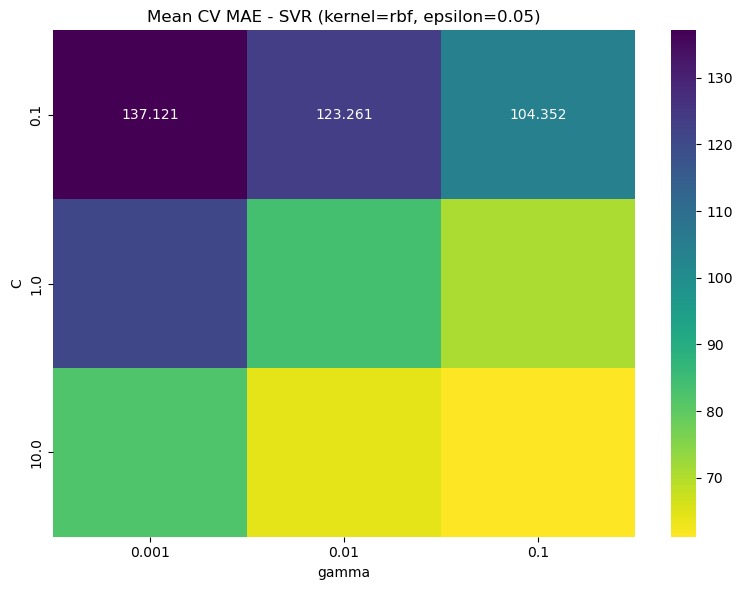

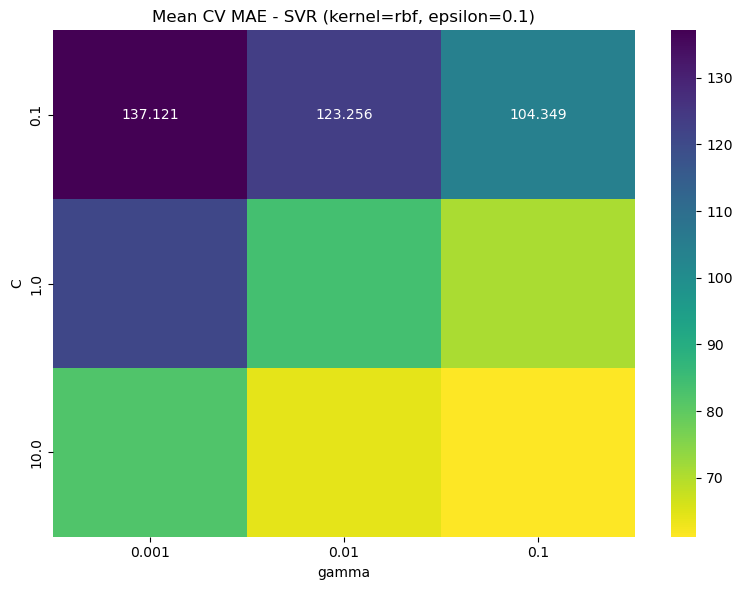

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# 1. Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])


# 2. Validación cruzada temporal en cadena
tscv = TimeSeriesSplit(n_splits=5)

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    print(f"\nFold {i}")
    print("Train fechas:", train_df.iloc[train_idx]["Fecha"].min(), "->", train_df.iloc[train_idx]["Fecha"].max())
    print("Val fechas  :", train_df.iloc[val_idx]["Fecha"].min(), "->", train_df.iloc[val_idx]["Fecha"].max())


# 3. Grid de hiperparámetros
param_grid = {
    "svr__C": [0.1, 1, 10],
    "svr__epsilon": [0.05, 0.1],
    "svr__gamma": [0.001, 0.01, 0.1]
}


# 4. GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=2,
    verbose=1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("\nMejores parámetros:")
print(grid.best_params_)

print("\nMejor score CV (MAE):")
print(-grid.best_score_)

# 5. Resultados del grid=
results = pd.DataFrame(grid.cv_results_).copy()

# Convertir score negativo a MAE positivo
results["mean_MAE"] = -results["mean_test_score"]


# 6. Heatmaps: uno por epsilon
epsilons = sorted(results["param_svr__epsilon"].unique(), key=float)

for eps in epsilons:
    sub = results[results["param_svr__epsilon"] == eps].copy()

    heatmap_data = sub.pivot(
        index="param_svr__C",
        columns="param_svr__gamma",
        values="mean_MAE"
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="viridis_r",
        annot_kws={"color": "black"}
   )

    plt.title(f"Mean CV MAE - SVR (kernel=rbf, epsilon={eps})")
    plt.xlabel("gamma")
    plt.ylabel("C")
    plt.tight_layout()
    plt.show()

# 7.5. Test final

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = grid.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nTest MAE:", mae)
print("Test RMSE:", rmse)